# Snapshot comparison

This notebook compares a **candidate** BCSD run against a global **snapshot** baseline,
leaf by leaf, under the per-variable tolerances. The candidate and the snapshot are
separate stores read on their own icechunk branches (`candidate_branch`,
`snapshot_branch`) and these need not match. The South Africa candidate is produced over
a small **halo** beyond the region of interest, because BCSD's regrid and spatial
disaggregation have edge effects at the domain boundary; `roi_bounds` trims both runs
back to the region of interest (`mode = "southafrica"`) so only interior cells, which had
full neighborhoods in both runs, are compared. For the full change-detected path
(`mode = "global"`) a global candidate is compared against the global snapshot as-is. See
`docs/explanation/snapshot-testing.md` for why this check exists and how the merge
decision is made.

The notebook runs in five passes:

| pass | cell | what it answers |
|---|---|---|
| open and align | *Open the two runs* | do both stores read, and does the snapshot subset onto the candidate's grid |
| inventory | *Leaf inventory* | did the candidate write every leaf its configs asked for, and do the two trees hold the same leaves |
| diff | *Compare* | does any leaf drift beyond its per-variable tolerance, and does `tasmax >= tasmin` hold |
| NaN audit | *Candidate NaN audit* | does the candidate hold a NaN anywhere inside the region of interest |
| plots | heatmap, maps, distributions | where and how the moving leaves move |

It is parameterized with [papermill](https://papermill.readthedocs.io/): the first code
cell is tagged `parameters`, so `snapshot_uri`, `snapshot_branch`, `candidate_uri`,
`candidate_branch`, `mode`, `roi_bounds`, `config_path`, `scenarios`, `variables`, and
`time_index` can be overridden at execution time.

## What this run is expected to show

The candidate is `v0.12.0.post21`, the `v0.12.0` tag plus the commits on branch
`g6-end-lineage-bridge`, and the baseline is `v0.12.0` from `srm.snapshot.baselines`. The
two runs share a tag, so everything already merged drops out and a leaf that moves here
moves because of this branch.

Unlike previous runs the two stores do **not** hold the same leaf set, because this branch
adds coverage rather than only changing numbers:

| | leaves | reading |
|---|---|---|
| shared | 50 | compared under tolerance |
| candidate only | 36 | new coverage, listed below |
| baseline only | 0 | nothing the baseline held went missing |

The 36 candidate-only leaves are `g6_1p5k_end` (14 including `debiased_coarse`),
`g6_1p5k/002` (14), and `historical/r2i1p1f1` (8). The termination scenario is new, member
`002` is newly published as its continued-SAI counterpart, and `r2i1p1f1` is the historical
parent the standard variables of member `002` resolve to, which member `003` never needed.
They have no baseline counterpart, so the comparison reports them one-sided; that is the
expected reading here, not a failure.

### The 50 shared leaves should not move

The bridge change only fires where `sai_parent` is set, which is `G6-1.5K-END` alone, so it
cannot touch `g6_1p5k/003` or `ssp245`. Nothing else on the branch changes a number: the
lineage tuple widened, the `predict_period_start` guard rejects configs rather than
altering them, and the reconciliation tooling only reads. So every one of the 50 shared
leaves should land within tolerance, and one that does not is a real finding.

Baseline-only leaves are the signal that matters most here. Zero of them means no task
aborted and no previously covered leaf vanished while the leaf set was growing.


In [1]:
from srm.snapshot.baselines import CESM2_WACCM_GLOBAL

snapshot_uri = CESM2_WACCM_GLOBAL.uri
# Read from baselines.py rather than hardcoded here, so "which run is the baseline" stays
# a single version-controlled value. It resolves to v0.12.0, the published production run;
# the candidate is that same tag plus this branch's commits, which is what makes the diff
# attributable.
snapshot_branch = CESM2_WACCM_GLOBAL.branch
# The candidate is a separate store on its own branch; it need not match the snapshot.
# Set candidate_branch to whatever branch your SA run wrote to (the installed package
# version by default, unless you set BCSD_BRANCH when producing it).
candidate_uri = (
    "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk"
)
candidate_branch = "v0.12.0.post21"
# "southafrica" = cheap check (subset the global snapshot to the candidate's extent);
# "global" = full change-detected path (candidate already global, no subset).
mode = "southafrica"
# The SA candidate is produced over a ~3 deg halo. roi_bounds trims both runs back to
# the region of interest before comparing, excluding BCSD edge effects at the halo
# boundary. [lat_min, lat_max, lon_min, lon_max]; set to None to compare the full extent.
roi_bounds = [-35, -22, 16, 33]
# Configs the candidate was produced from, relative to the repository root. The inventory
# cell loads them through the same loader `bcsd run` uses, so it can tell a leaf that was
# never configured from one that was configured and never written (a task aborted by an
# assert_no_nans gate, for instance).
config_path = "configs/snapshot/cesm2-waccm"
scenarios = None  # None = all groups; or e.g. ["g6_1p5k"]
variables = None  # None = all; or e.g. ["tas", "pr"]
time_index = 0

## Open the two runs

Opening the stores and aligning them onto a common grid is kept separate from diffing
them, so the inventory pass below can see both leaf sets exactly as they were read, before
any subsetting drops an unmatched node. Nothing here reads array data, so this cell is
fast even against the global store; the reductions all happen further down.

In [2]:
import xarray as xr

from srm.snapshot.compare import _iter_leaf_datasets
from srm.validation import _open_output_datatree


def crop_to_roi(ds, bounds):
    """Select the cells of ``ds`` inside [lat_min, lat_max, lon_min, lon_max]."""
    lat_min, lat_max, lon_min, lon_max = bounds
    idx = {}
    if "lat" in ds.coords:
        idx["lat"] = ds.lat[(ds.lat >= lat_min) & (ds.lat <= lat_max)]
    if "lon" in ds.coords:
        idx["lon"] = ds.lon[(ds.lon >= lon_min) & (ds.lon <= lon_max)]
    return ds.sel(idx) if idx else ds


candidate_tree = _open_output_datatree(candidate_uri, branch=candidate_branch)
snapshot_tree = _open_output_datatree(snapshot_uri, branch=snapshot_branch)

# Leaf paths as read, captured before the subsetting below drops anything. The inventory
# cell diffs these, so a leaf present on only one side is reported rather than lost.
candidate_paths = {path for path, _ in _iter_leaf_datasets(candidate_tree)}
snapshot_paths = {path for path, _ in _iter_leaf_datasets(snapshot_tree)}

if mode == "southafrica":
    # Trim the candidate to the region of interest (drop the halo), then subset the
    # global snapshot to those exact cells. Plain .sel: raises if a coordinate is
    # missing, so grid drift fails loudly (no coordinate resetting).
    cand_leaves = {
        path: (crop_to_roi(ds, roi_bounds) if roi_bounds else ds)
        for path, ds in _iter_leaf_datasets(candidate_tree)
    }
    snap_subset = {}
    for path, snap_ds in _iter_leaf_datasets(snapshot_tree):
        c = cand_leaves.get(path)
        if c is None:
            # Snapshot-only leaf: the global baseline can carry ensemble members the
            # regional candidate never ran (e.g. historical/tas/r1i1p1f1). Dropping it
            # keeps the subset tree on the candidate's extent, since an unmatched leaf
            # would otherwise be copied through at the full global 721x1440. It is
            # *reported* by the inventory cell rather than silently skipped, because a
            # task aborted by an assert_no_nans gate would present the same way.
            continue
        idx = {d: c[d] for d in ("lat", "lon") if d in c.coords and d in snap_ds.coords}
        if idx:
            snap_ds = snap_ds.sel(idx)
        snap_subset["/" + path if path else "/"] = snap_ds
    candidate_tree = xr.DataTree.from_dict(
        {"/" + p if p else "/": ds for p, ds in cand_leaves.items()}
    )
    snapshot_tree = xr.DataTree.from_dict(snap_subset)

print(f"candidate {candidate_branch}: {len(candidate_paths)} leaves at {candidate_uri}")
print(f"snapshot  {snapshot_branch}: {len(snapshot_paths)} leaves at {snapshot_uri}")

candidate v0.12.0.post21: 86 leaves at s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk
snapshot  v0.12.0: 50 leaves at s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk


## Leaf inventory

A leaf the candidate never wrote is not the same thing as a leaf that drifted, and the
tolerance report cannot tell them apart on its own: the subsetting above drops any leaf
missing from the candidate, so an aborted task would leave no trace in the diff. With the
`assert_no_nans` gates in place a task can now abort mid-run, which makes this the check
that turns that into a visible failure.

The expected leaf set comes from the snapshot configs themselves, loaded through
`srm.cli.load_configs`, the same loader `bcsd run` used to submit them. Only scenario
groups are reconstructed. `historical` leaves are keyed by *lineage* member rather than
the configured one (`tas` takes `r3i1p1f1` while `tasmax` takes `001`), so rebuilding them
here would duplicate `srm.lineage`; the candidate-versus-snapshot leaf diff covers them
instead.

In [3]:
import pathlib

from srm.cli import load_configs
from srm.config import SCENARIO_TO_GROUP


def repo_root() -> pathlib.Path:
    """Nearest ancestor of the working directory that holds pyproject.toml."""
    here = pathlib.Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(f"could not locate the repository root from {here}")


configs, config_options = load_configs(str(repo_root() / config_path))
configured = {f"{SCENARIO_TO_GROUP[c.scenario]}/{c.variable}/{c.ensemble_member}" for c in configs}
# debiased_coarse mirrors the scenario groups one level down and is compared, but it is
# not what the configs enumerate, so it is excluded from the expected-set diff.
written = {path for path in candidate_paths if not path.startswith("debiased_coarse")}

never_written = sorted(configured - written)
snapshot_only = sorted(snapshot_paths - candidate_paths)
candidate_only = sorted(candidate_paths - snapshot_paths)
inventory_ok = not (never_written or snapshot_only or candidate_only)

print("INVENTORY:", "PASS" if inventory_ok else "FAIL")
print(f"  {len(configs)} configs -> {len(configured)} configured scenario-group leaves")
print(f"  candidate holds {len(candidate_paths)} leaves, snapshot holds {len(snapshot_paths)}")
if config_options.branch != candidate_branch:
    # Not a failure: the configs' default branch tracks the *installed* package version,
    # which moves when you reinstall. Worth seeing, because reading the wrong branch is
    # the easiest way to compare against a run you did not just produce.
    print(
        f"  note: configs default to branch {config_options.branch!r}, reading {candidate_branch!r}"
    )
for label, paths in (
    ("configured but never written by the candidate", never_written),
    ("in the snapshot only, dropped from the diff", snapshot_only),
    ("in the candidate only, reported as a mismatch", candidate_only),
):
    for path in paths:
        print(f"  {label}: {path}")

INVENTORY: FAIL
  32 configs -> 32 configured scenario-group leaves
  candidate holds 86 leaves, snapshot holds 50
  note: configs default to branch 'v999', reading 'v0.12.0.post21'
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/dtr/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/hurs/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/pr/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/rsds/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/tas/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/tasmax/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k/tasmin/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k_end/dtr/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k_end/hurs/002
  in the candidate only, reported as a mismatch: debiased_coarse/g6_1p5k_

## Compare

`_compare_datatrees` reduces every leaf to `max_abs_diff`, `rmse`, `frac_over_tol`, and
`nan_mismatch_count` under the per-variable tolerances in `srm.snapshot.tolerances`, then
runs the `tasmax >= tasmin` invariant on the candidate alone. `nan_mismatch_count` is
printed here because it is what separates the two ways a leaf can fail: a value that moved,
or a cell that is NaN on one side and finite on the other.

In [4]:
from srm.snapshot.runs import _compare_datatrees

report = _compare_datatrees(candidate_tree, snapshot_tree, scenarios=scenarios, variables=variables)

# OVERALL folds two verdicts: no leaf drifted beyond tolerance vs the snapshot, and the
# candidate's tasmax >= tasmin invariant holds (a broken reconcile can pass every leaf
# individually yet invert the pair; see report.invariant_checks below).
print("OVERALL:", "PASS" if report.passed else "FAIL")
print(f"      {'leaf':44s} {'max_abs':>11s} {'rmse':>11s} {'frac>tol':>10s} {'nan_mism':>9s}")
for leaf in sorted(report.leaves, key=lambda lf: lf.path):
    flag = "ok " if leaf.within_tol else "OUT"
    print(
        f"[{flag}] {leaf.path:44s} {leaf.max_abs_diff:11.3e} {leaf.rmse:11.3e} "
        f"{leaf.frac_over_tol:10.3e} {leaf.nan_mismatch_count:9d}"
    )
for check in sorted(report.invariant_checks, key=lambda c: c.path):
    flag = "ok " if check.holds else "OUT"
    print(f"[{flag}] {check.path:44s} {check.detail}")

# Roll-up by group. The model_hist fix (issue #518) is expected to move g6_1p5k and leave
# ssp245 and historical alone, so the verdict is most legible split this way.
tallies: dict[str, list[int]] = {}
for leaf in report.leaves:
    parts = leaf.path.split("/")
    key = "debiased_coarse/" + parts[1] if parts[0] == "debiased_coarse" else parts[0]
    tally = tallies.setdefault(key, [0, 0])
    tally[0] += 1
    tally[1] += 0 if leaf.within_tol else 1
print()
for key in sorted(tallies):
    total, out = tallies[key]
    print(f"  {key:28s} {total - out:2d}/{total:2d} leaves within tolerance")

OVERALL: FAIL
      leaf                                             max_abs        rmse   frac>tol  nan_mism
[OUT] debiased_coarse/g6_1p5k/dtr/002/dtr                  nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/dtr/003/dtr            1.011e-04   8.914e-07  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/hurs/002/hurs                nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/hurs/003/hurs          4.120e-04   4.599e-06  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/pr/002/pr                    nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/pr/003/pr              1.746e-10   2.926e-12  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/rsds/002/rsds                nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1p5k/rsds/003/rsds          3.891e-04   1.622e-05  0.000e+00         0
[OUT] debiased_coarse/g6_1p5k/tas/002/tas                  nan         nan  1.000e+00        -1
[ok ] debiased_coarse/g6_1

## Candidate NaN audit

Inside `roi_bounds` the candidate should hold no NaN at all. The fine cells that
interpolate to NaN by design sit in the halo, outside the region of interest (see
`srm.downscaling_utils.coarse_domain_mask`), and the `assert_no_nans` gates now abort a
task rather than write an interior NaN. So a nonzero candidate fraction here is a
regression, and it is the direct end-to-end check on issue #517.

Pairing that fraction with `nan_mismatch_count` from the report above tells you which side
holds the NaNs, without a second read of the global snapshot:

| candidate NaN frac | `nan_mismatch` | reading |
|---|---|---|
| 0 | 0 | both sides clean |
| 0 | > 0 | the **snapshot** holds the NaNs, so the fix landed |
| > 0 | > 0 | the **candidate** holds NaNs the baseline does not, so it is a regression |
| > 0 | 0 | both sides NaN at the same cells, so the bug predates the baseline |

This reduces over the full candidate extent, which is a few GB of regional reads in
`southafrica` mode and considerably more in `global` mode. It adds roughly one pass over
the candidate on top of what the compare cell already reads, and it touches only the
candidate, never the snapshot.

In [5]:
# nan_mismatch comes from the report above, so the global snapshot is not read again.
mismatch = {leaf.path: leaf.nan_mismatch_count for leaf in report.leaves}
nan_rows = []
for path, cand_ds in sorted(_iter_leaf_datasets(candidate_tree), key=lambda item: item[0]):
    for variable, cand_da in cand_ds.data_vars.items():
        leaf_path = f"{path}/{variable}"
        if leaf_path not in mismatch:
            continue  # filtered out by `scenarios` / `variables`
        nan_rows.append((leaf_path, float(cand_da.isnull().mean().compute()), mismatch[leaf_path]))

candidate_nan_leaves = [row for row in nan_rows if row[1] > 0]
print(
    "CANDIDATE NaN AUDIT:",
    "PASS (no NaN inside the region of interest)" if not candidate_nan_leaves else "FAIL",
)
print(f"      {'leaf':44s} {'cand nan frac':>14s} {'nan_mismatch':>13s}")
for leaf_path, frac, mism in nan_rows:
    flag = "ok " if frac == 0 else "NaN"
    print(f"[{flag}] {leaf_path:44s} {frac:14.6f} {mism:13d}")

CANDIDATE NaN AUDIT: PASS (no NaN inside the region of interest)
      leaf                                          cand nan frac  nan_mismatch
[ok ] debiased_coarse/g6_1p5k/dtr/002/dtr                0.000000            -1
[ok ] debiased_coarse/g6_1p5k/dtr/003/dtr                0.000000             0
[ok ] debiased_coarse/g6_1p5k/hurs/002/hurs              0.000000            -1
[ok ] debiased_coarse/g6_1p5k/hurs/003/hurs              0.000000             0
[ok ] debiased_coarse/g6_1p5k/pr/002/pr                  0.000000            -1
[ok ] debiased_coarse/g6_1p5k/pr/003/pr                  0.000000             0
[ok ] debiased_coarse/g6_1p5k/rsds/002/rsds              0.000000            -1
[ok ] debiased_coarse/g6_1p5k/rsds/003/rsds              0.000000             0
[ok ] debiased_coarse/g6_1p5k/tas/002/tas                0.000000            -1
[ok ] debiased_coarse/g6_1p5k/tas/003/tas                0.000000             0
[ok ] debiased_coarse/g6_1p5k/tasmax/002/tasmax        

## Where the leaves move

The heatmap gives one cell per compared leaf, colored by the fraction of grid cells over
tolerance. Rows are `variable/member` and columns are the scenario group, so sibling
members of the same variable stay distinct.

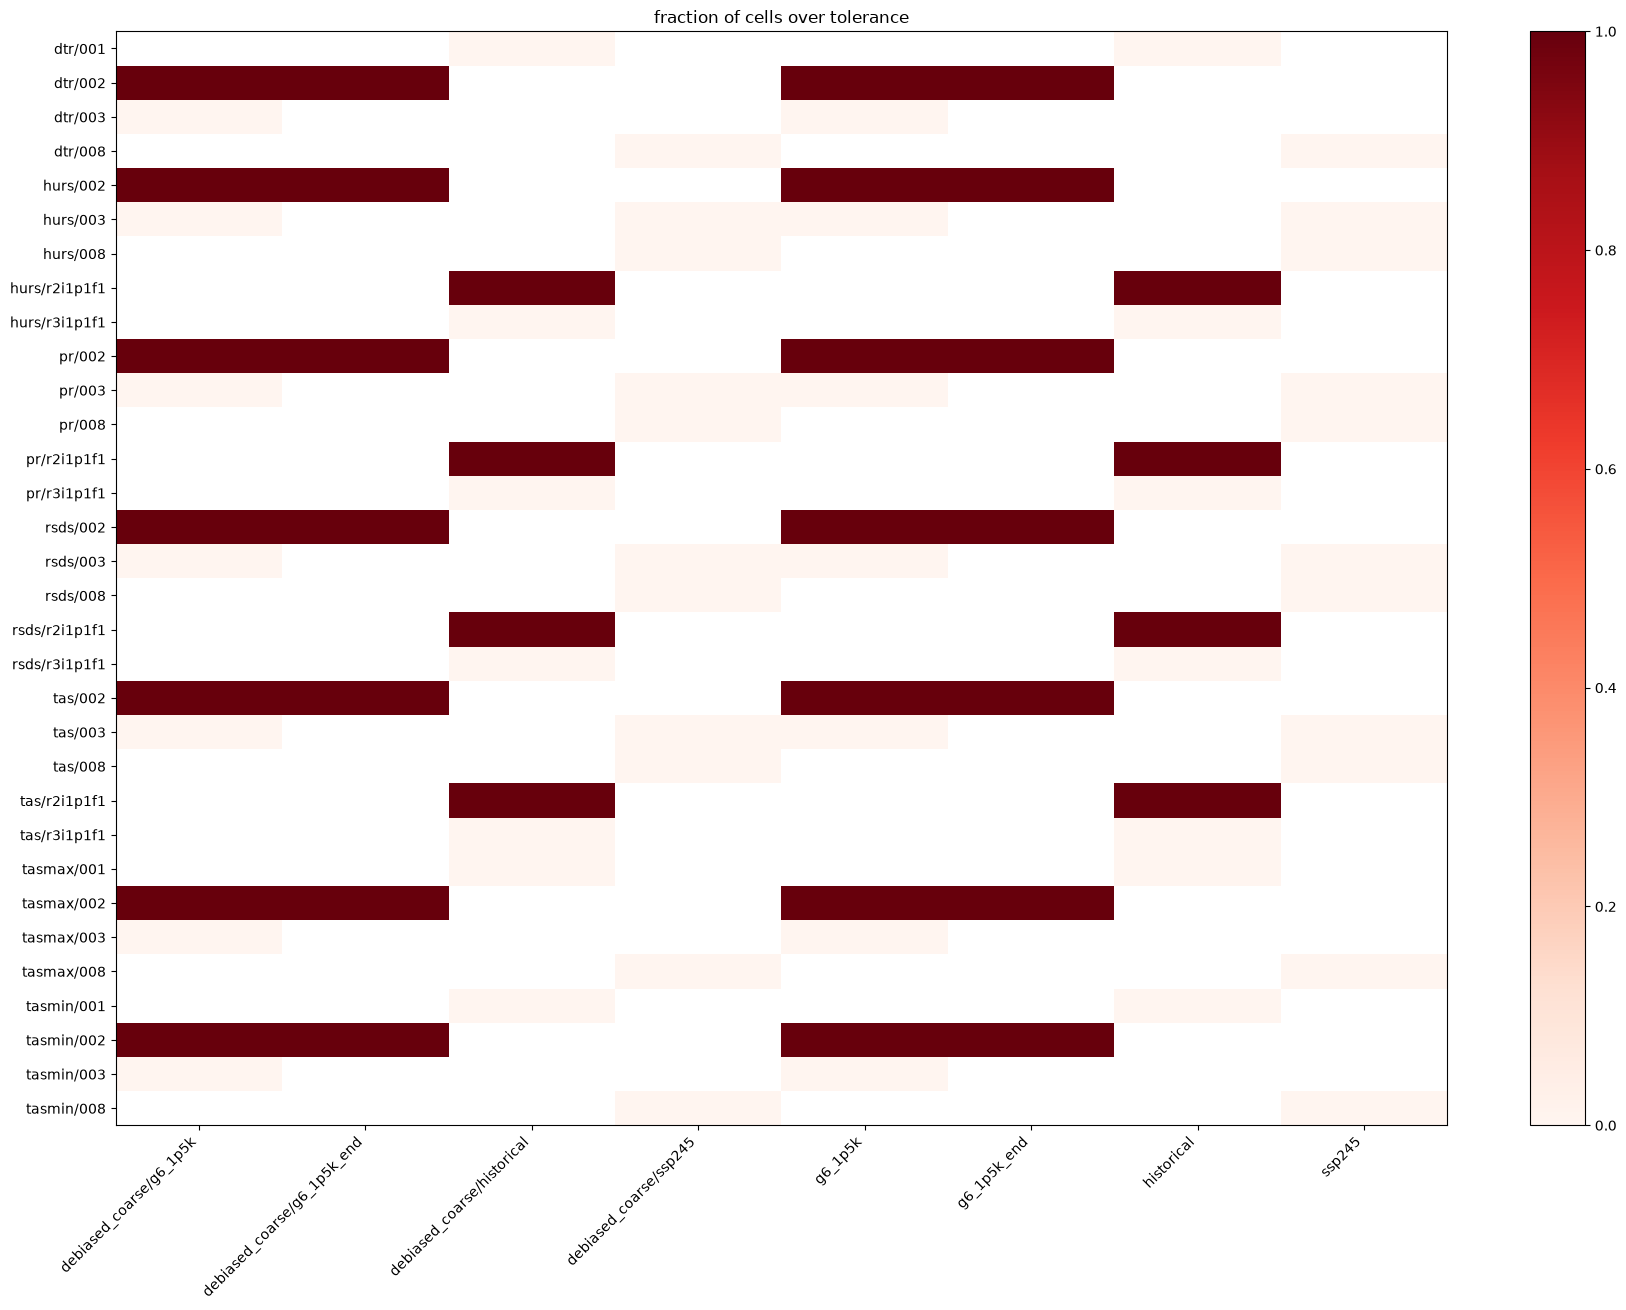

col,debiased_coarse/g6_1p5k,debiased_coarse/g6_1p5k_end,debiased_coarse/historical,debiased_coarse/ssp245,g6_1p5k,g6_1p5k_end,historical,ssp245
row,,,,,,,,
dtr/001,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
dtr/002,1.0,1.0,NaN,NaN,1.0,1.0,NaN,NaN
dtr/003,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
dtr/008,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,0.000000e+00
hurs/002,1.0,1.0,NaN,NaN,1.0,1.0,NaN,NaN
hurs/003,0.0,NaN,NaN,0.000000e+00,0.0,NaN,NaN,0.000000e+00
hurs/008,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,0.000000e+00
hurs/r2i1p1f1,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN
hurs/r3i1p1f1,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Rows are keyed on variable *and* member. Keying on the variable alone collapsed sibling
# members onto one cell (ssp245/tas/003 and ssp245/tas/008 landed together and one
# silently overwrote the other). Leaf paths are group/variable/member/variable, with an
# extra debiased_coarse prefix on the coarse family, so counting from the right is stable.
records = []
for leaf in report.leaves:
    parts = leaf.path.split("/")
    if len(parts) < 4:
        continue
    family = "debiased_coarse/" if parts[0] == "debiased_coarse" else ""
    group, variable, member = parts[-4], parts[-3], parts[-2]
    records.append(
        {
            "row": f"{variable}/{member}",
            "col": f"{family}{group}",
            "frac_over_tol": leaf.frac_over_tol,
        }
    )

if not records:
    raise ValueError("no leaves to plot; check the `scenarios` and `variables` filters")

grid = (
    pd.DataFrame(records)
    .pivot(index="row", columns="col", values="frac_over_tol")
    .sort_index()
    .sort_index(axis=1)
)
fig, ax = plt.subplots(figsize=(2.0 * len(grid.columns) + 2, 0.35 * len(grid.index) + 2))
im = ax.imshow(grid.to_numpy(), aspect="auto", cmap="Reds", vmin=0)
ax.set_xticks(range(len(grid.columns)), grid.columns, rotation=45, ha="right")
ax.set_yticks(range(len(grid.index)), grid.index)
ax.set_title("fraction of cells over tolerance")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
grid

In [7]:
# The report above covers all leaves (including debiased_coarse); the plots below focus
# on the final products for readability. candidate_tree and snapshot_tree (already
# subset for the southafrica mode) come from the open-the-runs cell, and
# SCENARIO_TO_GROUP from the inventory cell.
KNOWN_GROUPS = set(SCENARIO_TO_GROUP.values())
scen_list = scenarios or sorted(
    KNOWN_GROUPS & set(snapshot_tree.children) & set(candidate_tree.children)
)


def leaf_da(tree, scenario, variable, member):
    """Return the DataArray for one (scenario, variable, member) leaf.

    The member is passed in explicitly rather than discovered, because a leaf can hold
    several ensemble members (e.g. historical/tas has r1i1p1f1, r2i1p1f1, r3i1p1f1). The
    caller pairs snapshot and candidate on the *same* member via :func:`shared_members`,
    so the difference is always like-for-like.
    """
    return tree[f"{scenario}/{variable}/{member}"].to_dataset(inherit=False)[variable]


def shared_members(scenario, variable):
    """Ensemble members present under this leaf in both the snapshot and candidate.

    Sorted for a stable plot order. The global snapshot may carry members the regional
    candidate never ran; those are excluded so only comparable pairs are plotted.
    """
    snap = set(snapshot_tree[f"{scenario}/{variable}"].children)
    cand = set(candidate_tree[f"{scenario}/{variable}"].children)
    return sorted(snap & cand)

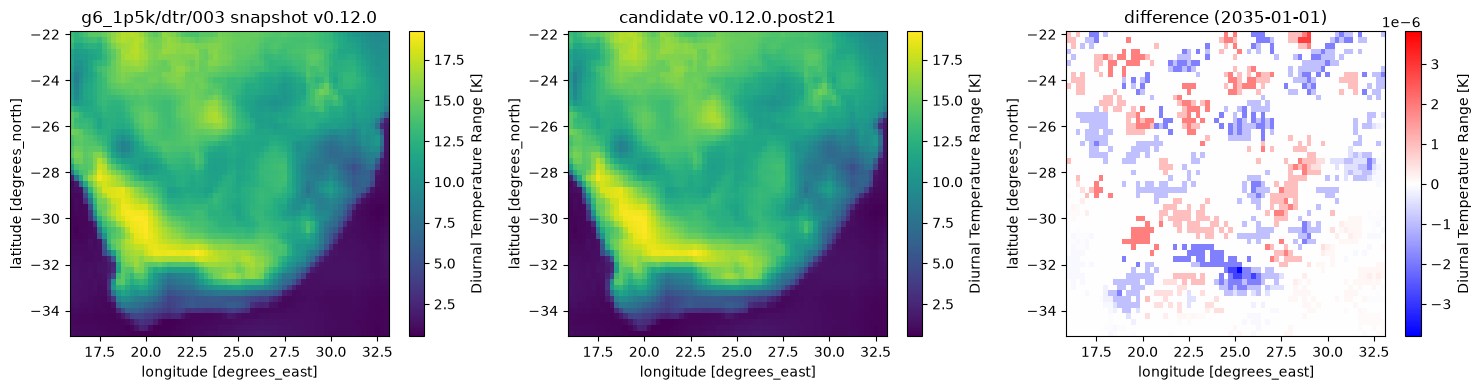

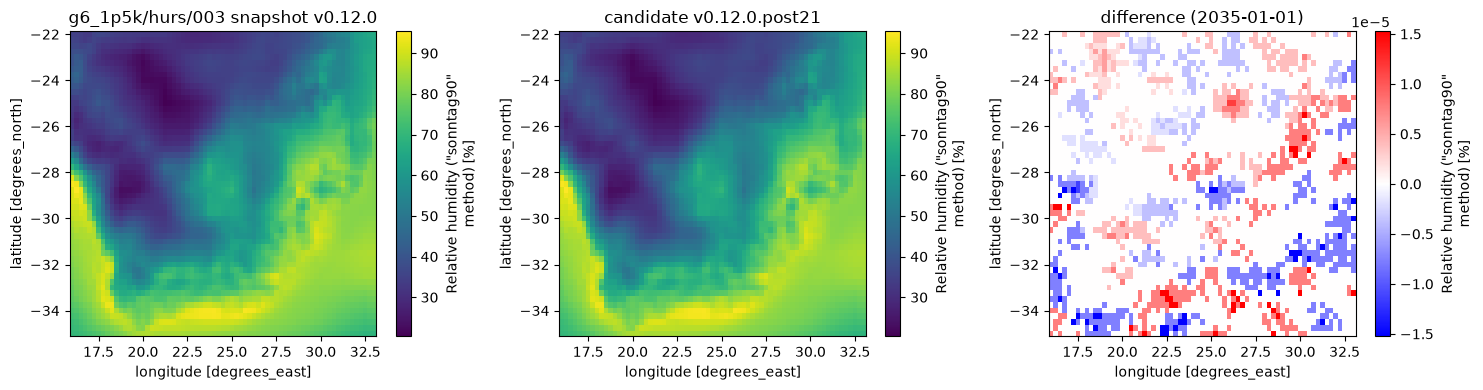

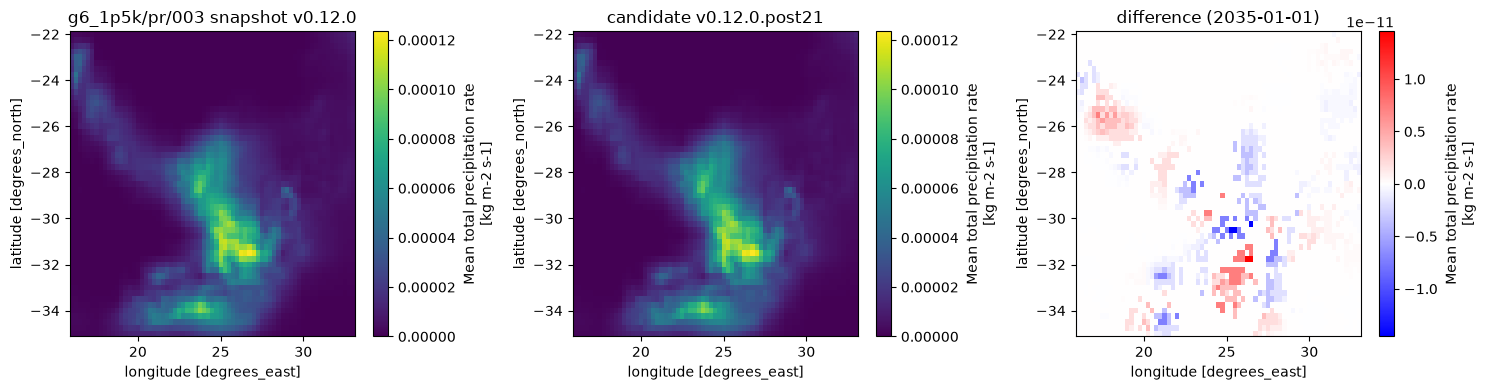

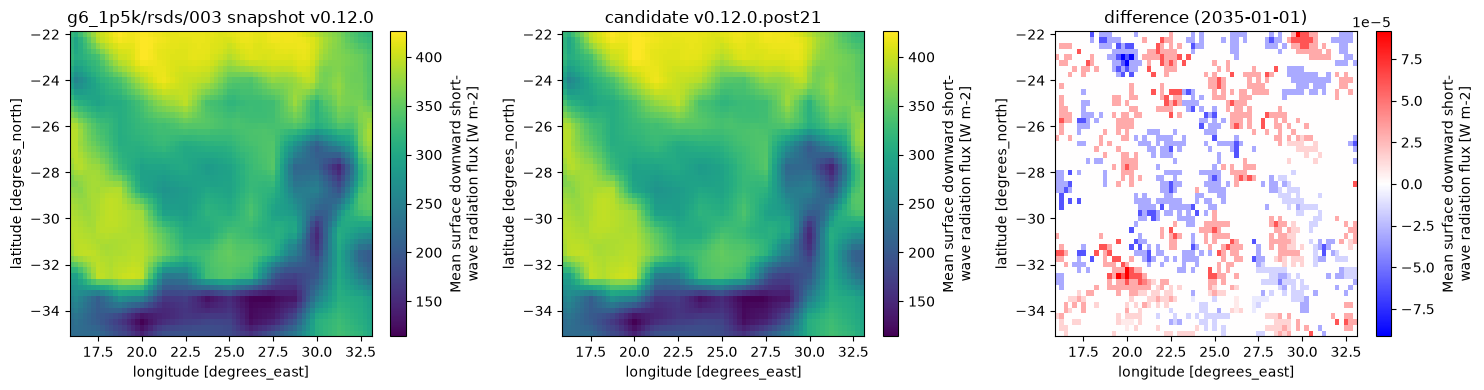

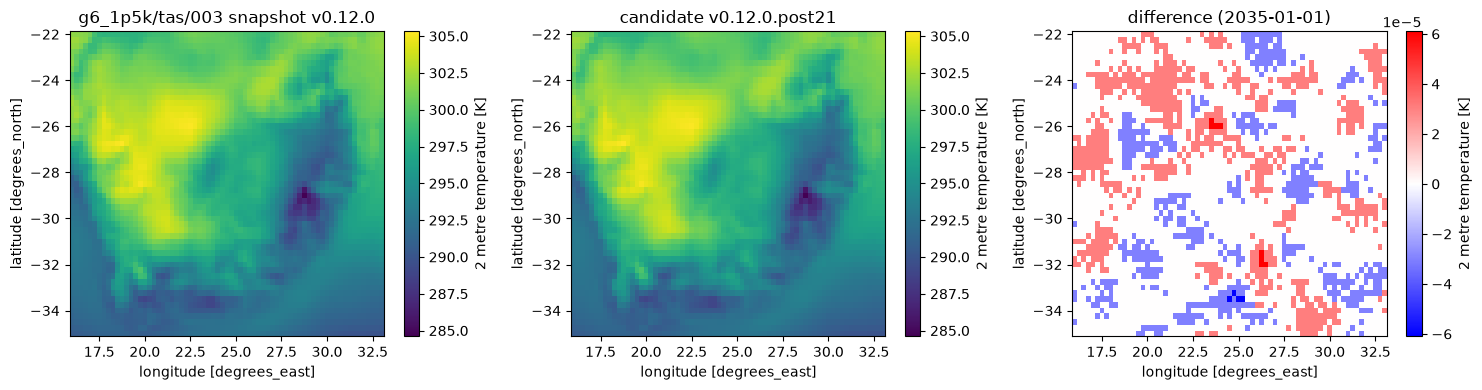

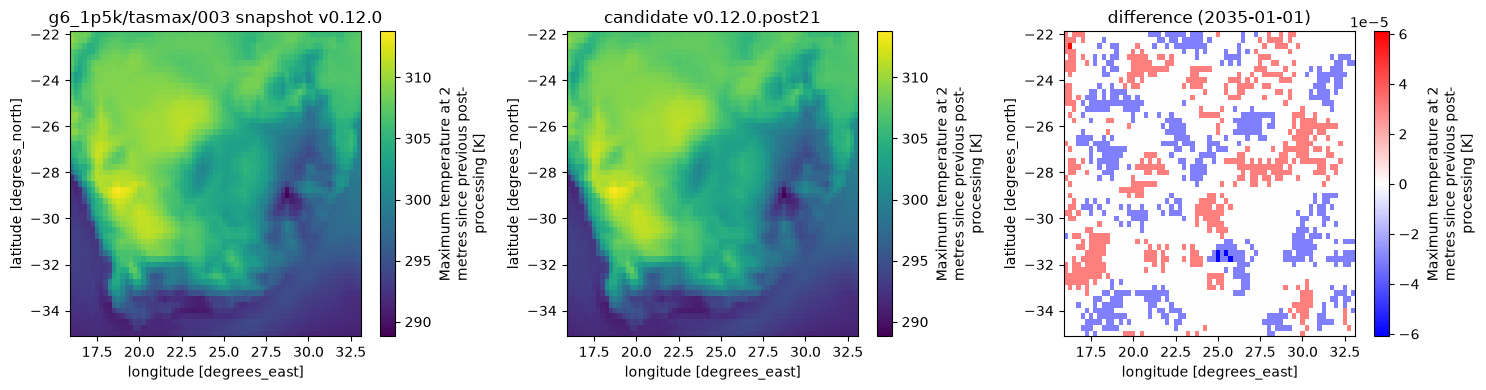

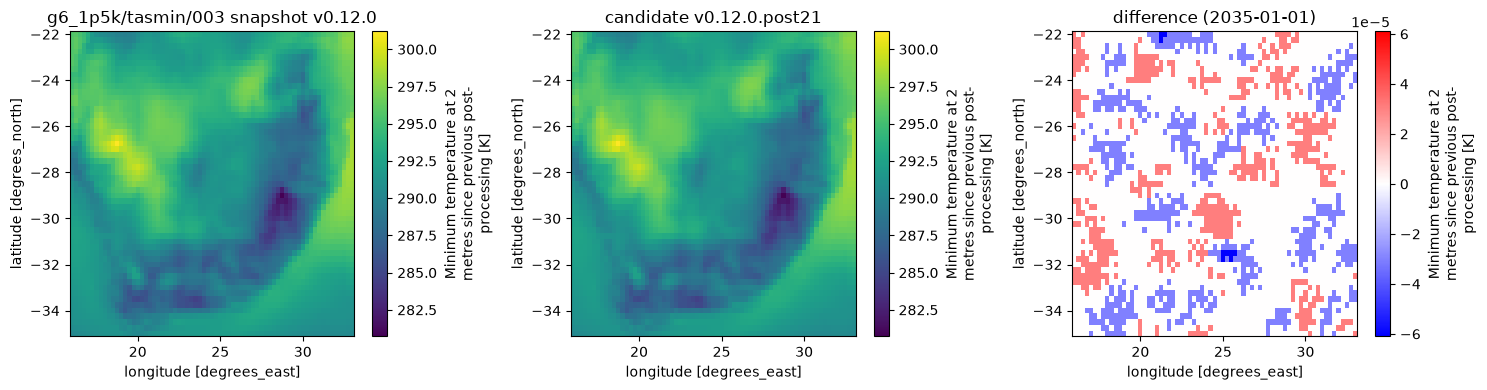

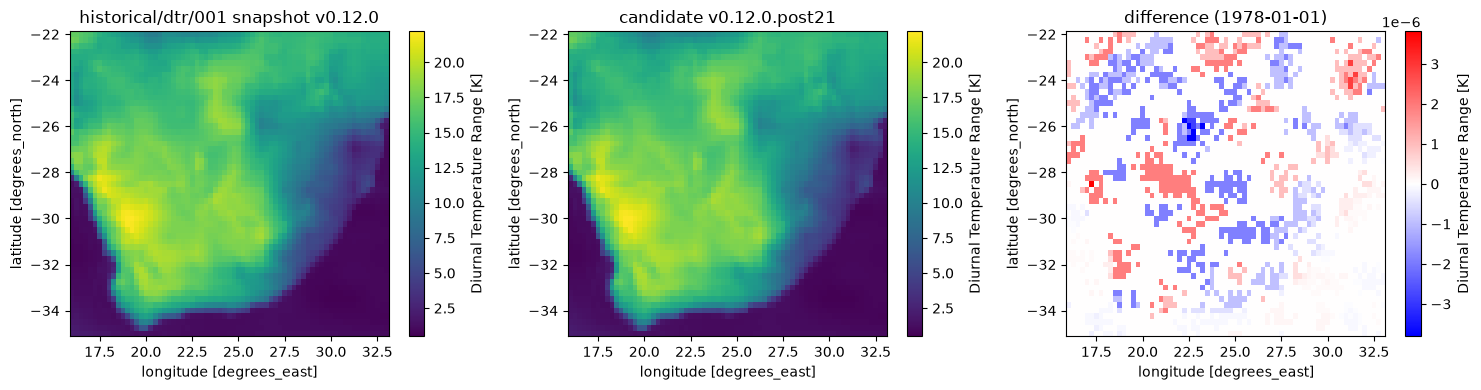

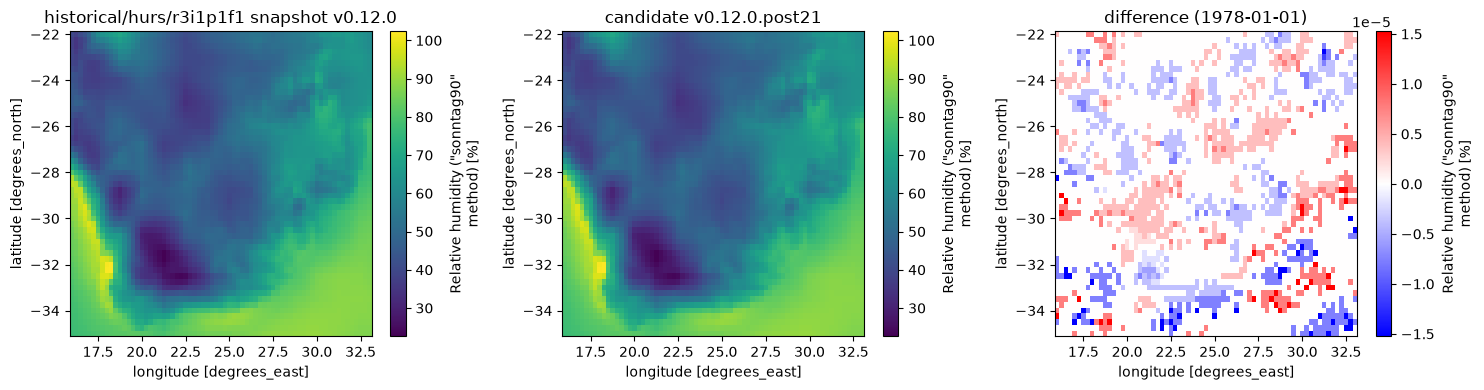

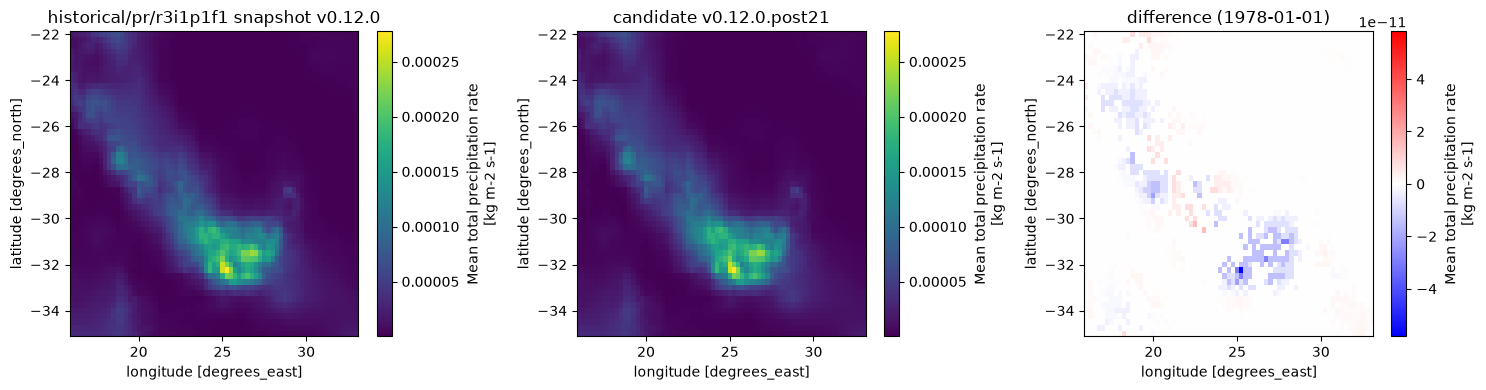

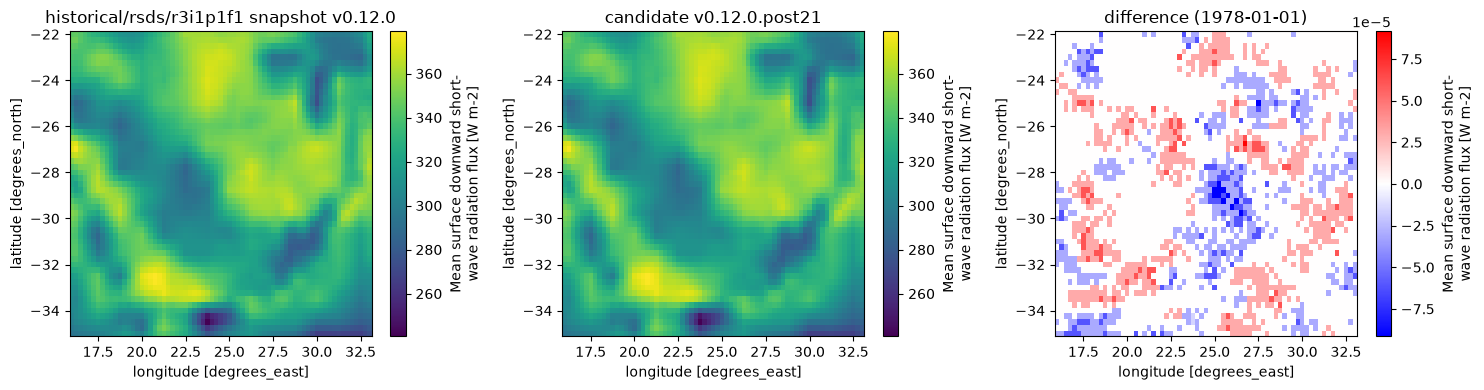

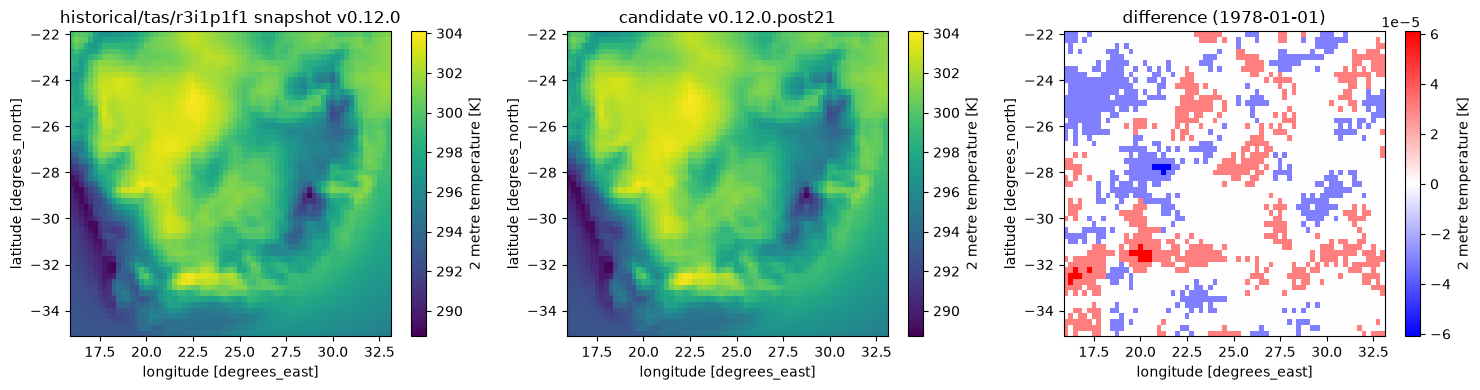

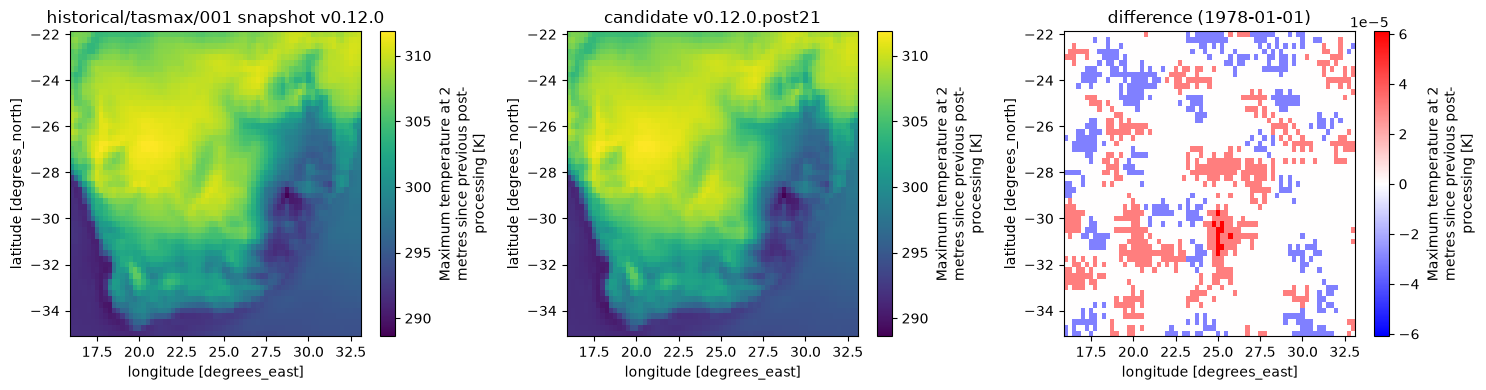

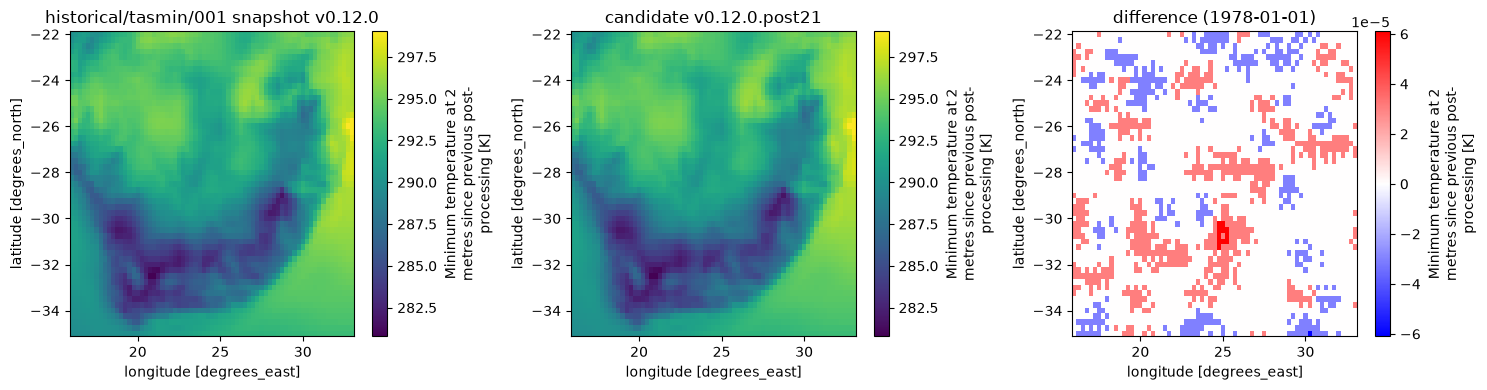

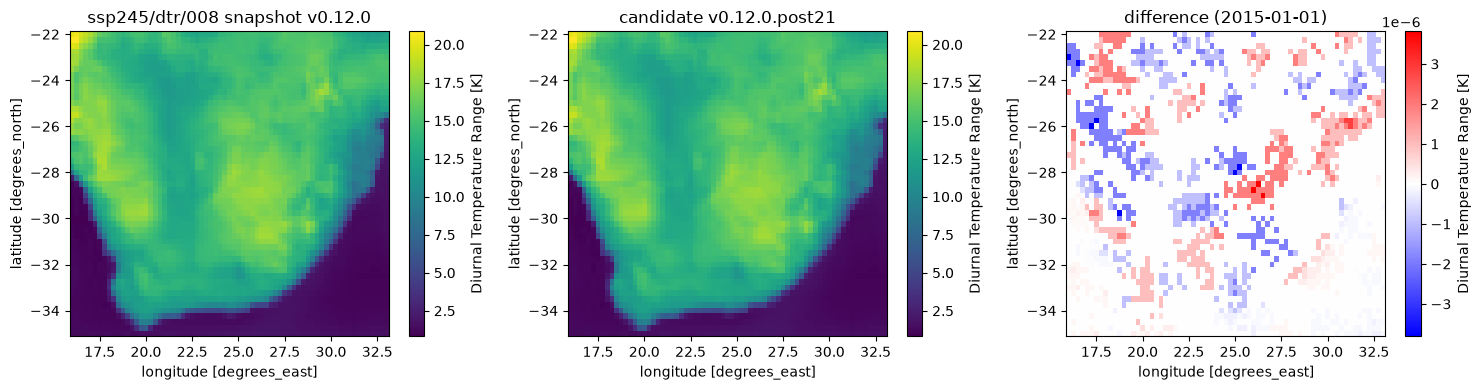

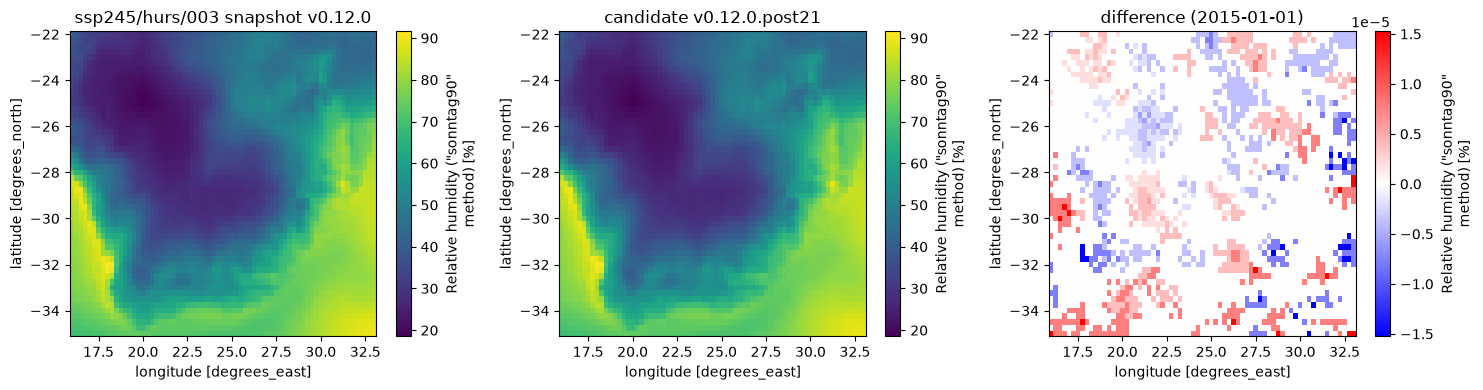

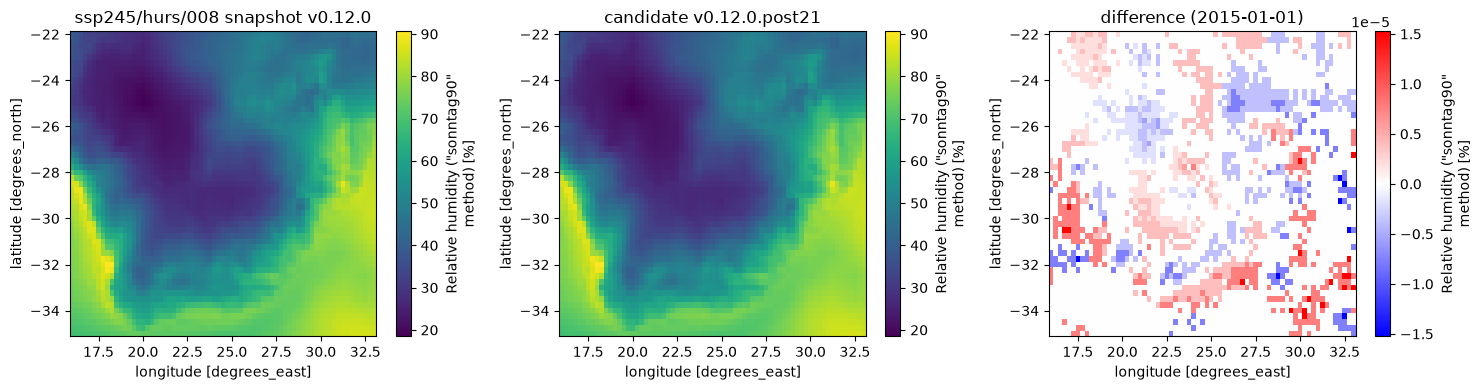

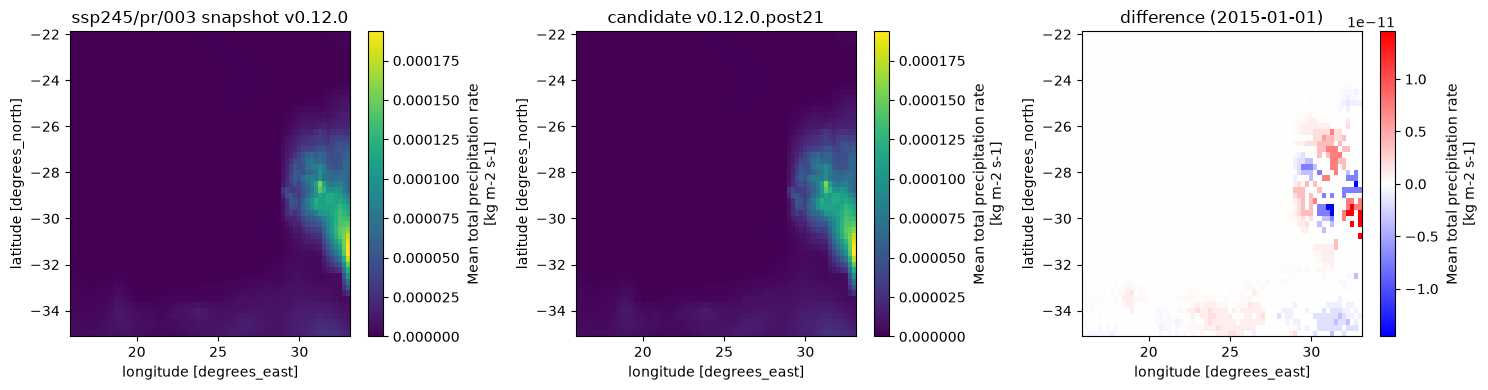

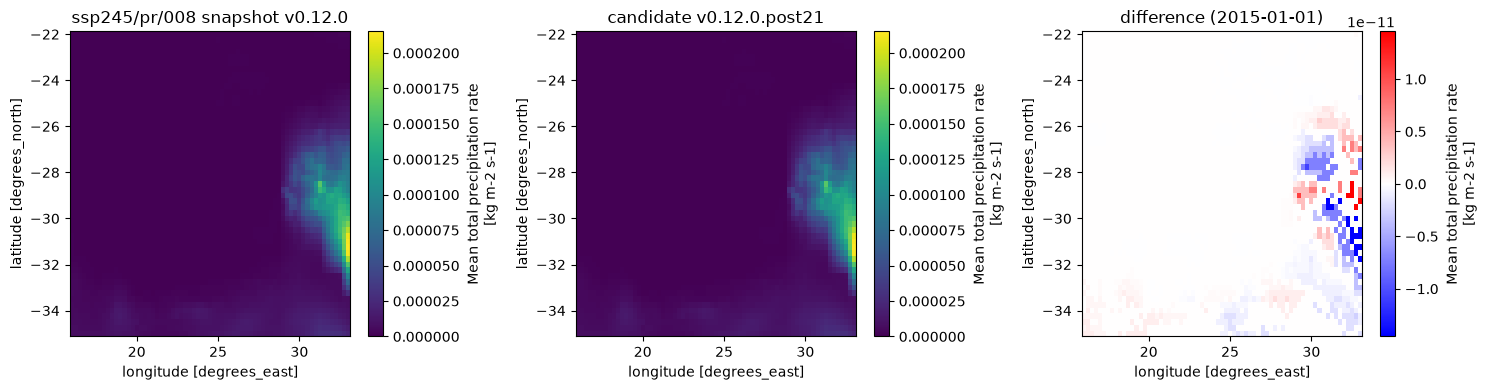

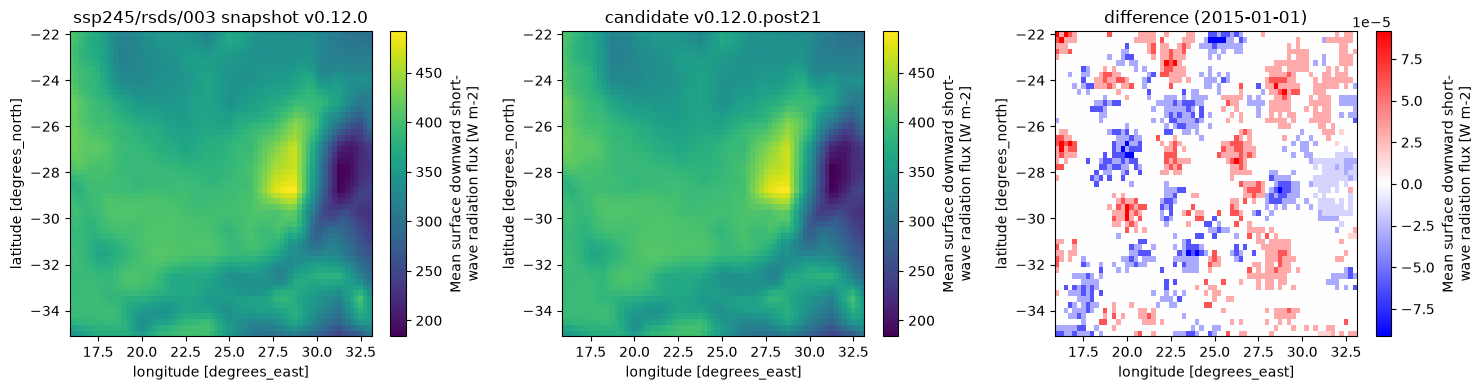

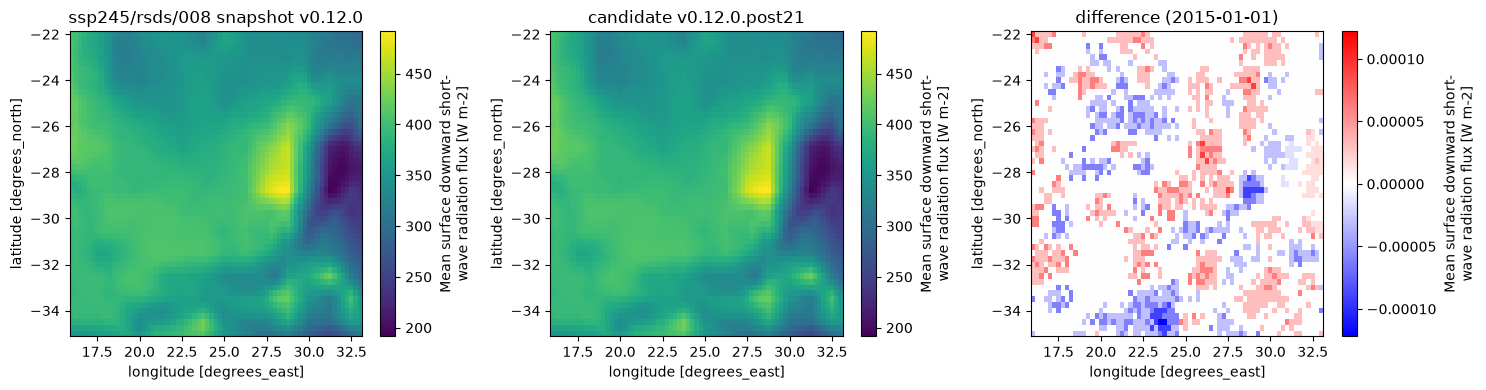

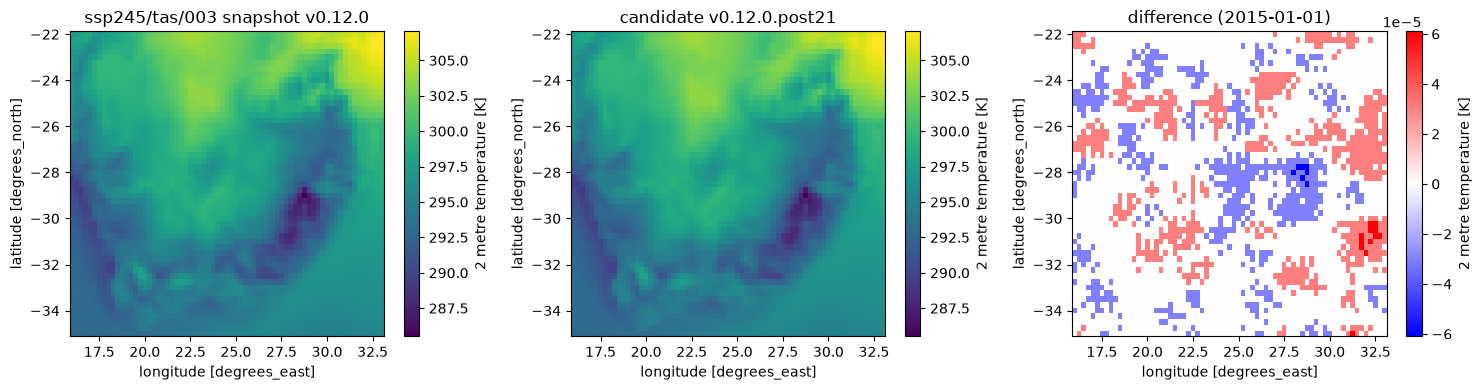

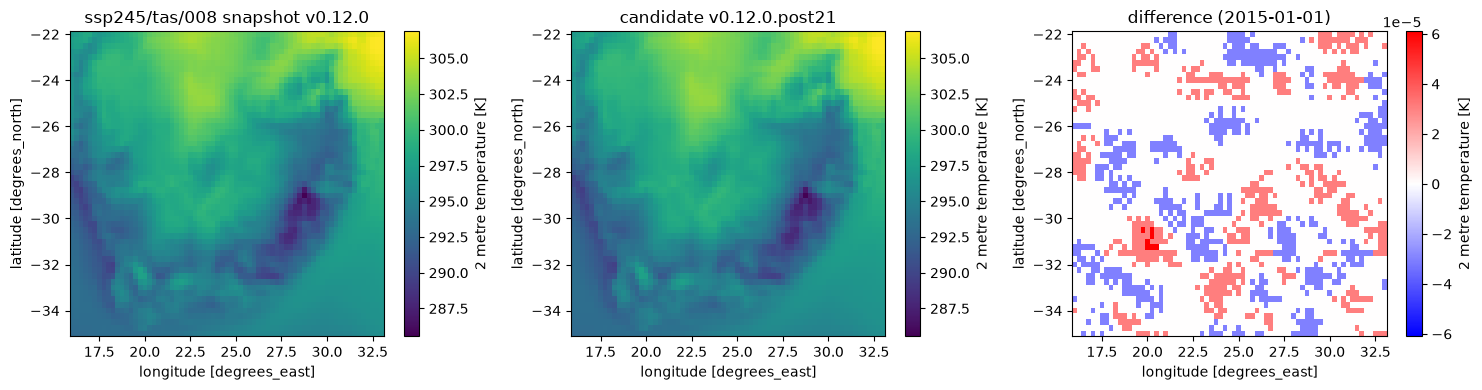

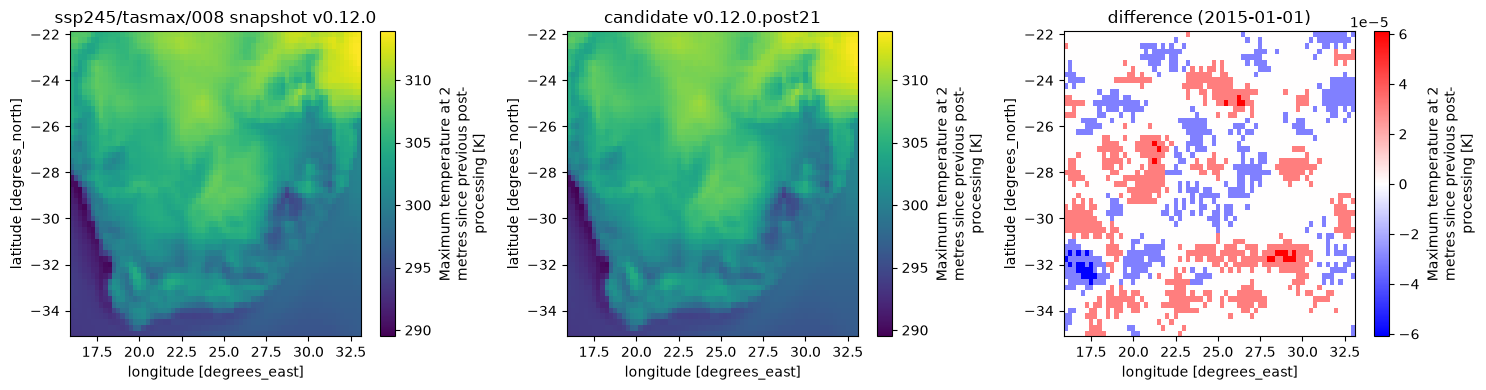

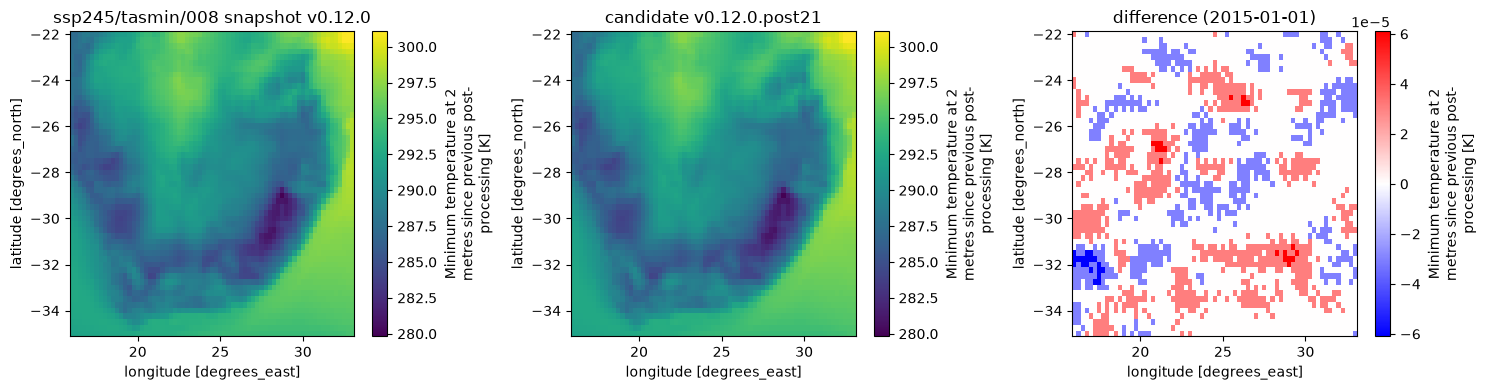

In [8]:
# Difference maps: snapshot vs candidate vs (candidate - snapshot) at one time step,
# one row of maps per ensemble member the two runs share.
for scenario in scen_list:
    snap_vars = set(snapshot_tree[scenario].children)
    cand_vars = set(candidate_tree[scenario].children)
    for variable in sorted(snap_vars & cand_vars):
        if variables and variable not in variables:
            continue
        for member in shared_members(scenario, variable):
            c0 = leaf_da(candidate_tree, scenario, variable, member).isel(time=time_index)
            # Select the snapshot by *label*, not position: isel on both sides would
            # silently compare different dates whenever the two time axes differ in
            # start or length, which is exactly the case a shape mismatch flags.
            s0 = leaf_da(snapshot_tree, scenario, variable, member).sel(time=c0["time"])
            date = str(c0["time"].values)[:10]
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            s0.plot(ax=axes[0])
            axes[0].set_title(f"{scenario}/{variable}/{member} snapshot {snapshot_branch}")
            c0.plot(ax=axes[1])
            axes[1].set_title(f"candidate {candidate_branch}")
            (c0 - s0).plot(ax=axes[2], cmap="bwr", center=0)
            axes[2].set_title(f"difference ({date})")
            plt.tight_layout()
            plt.show()

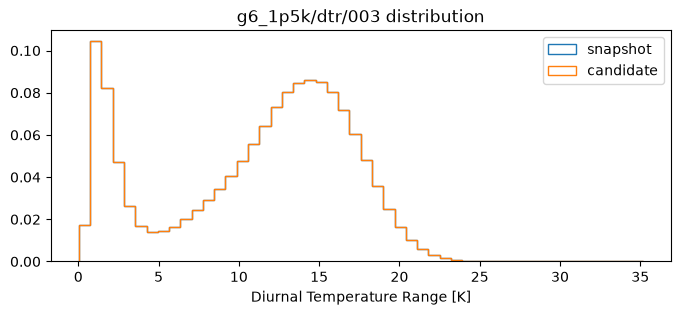

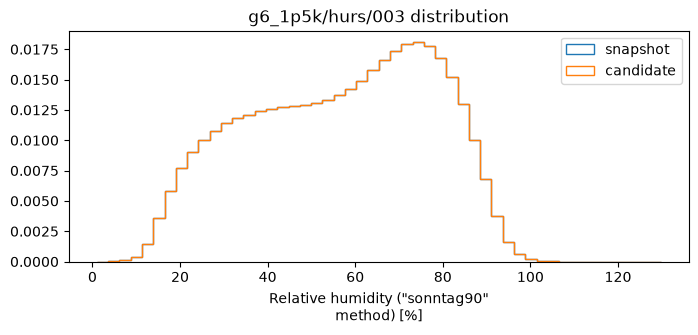

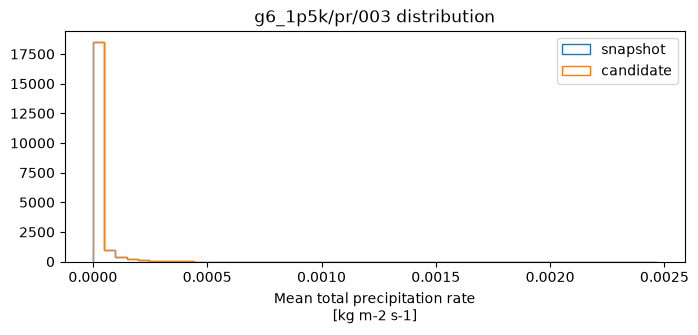

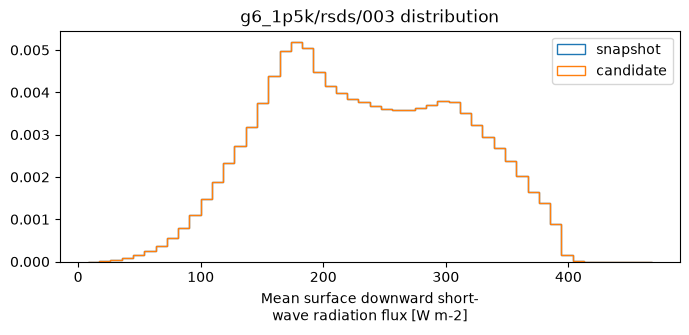

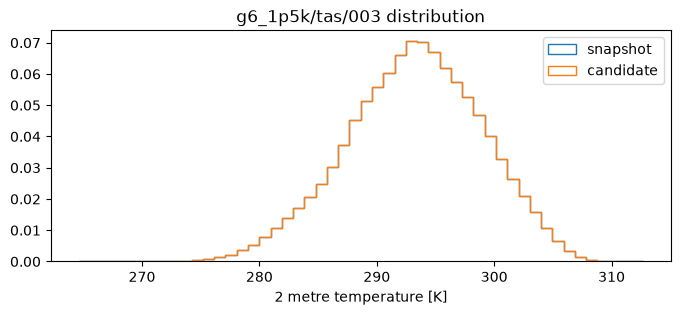

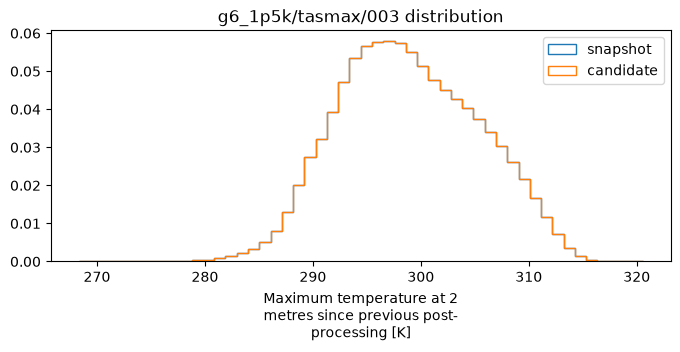

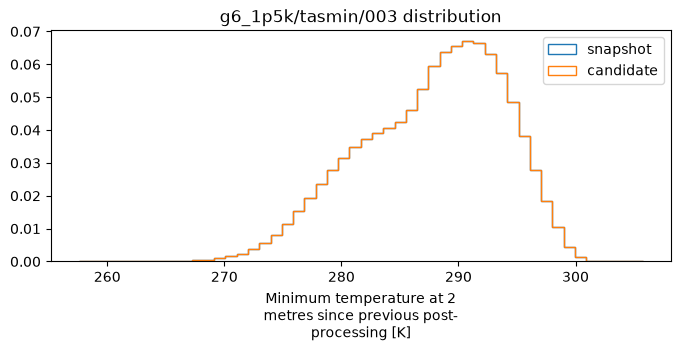

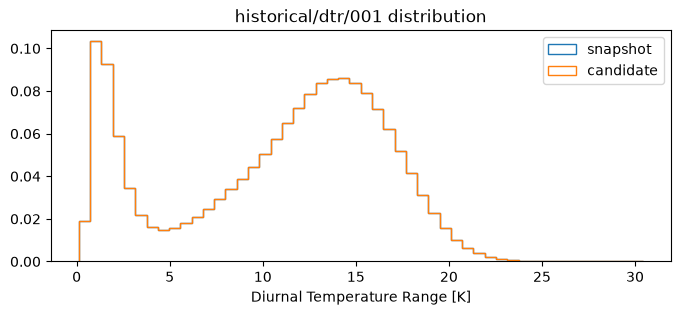

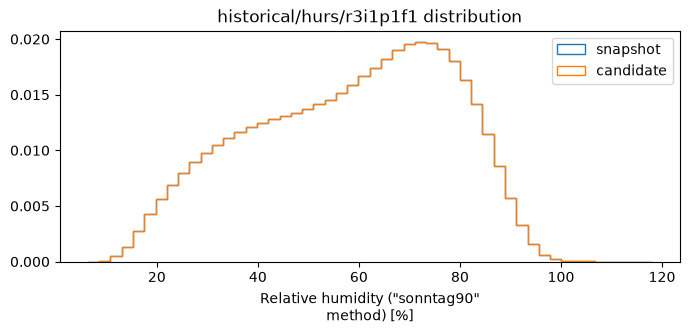

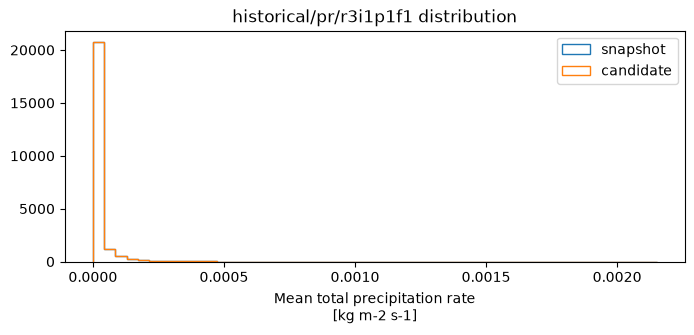

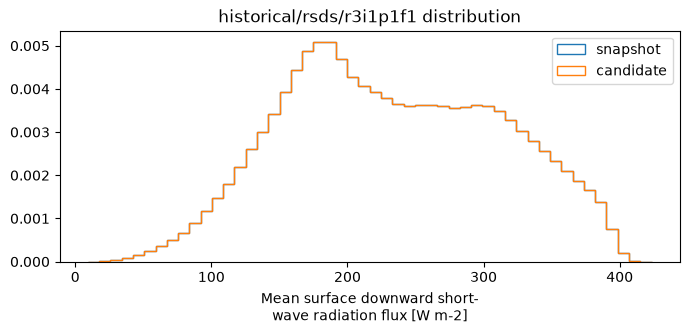

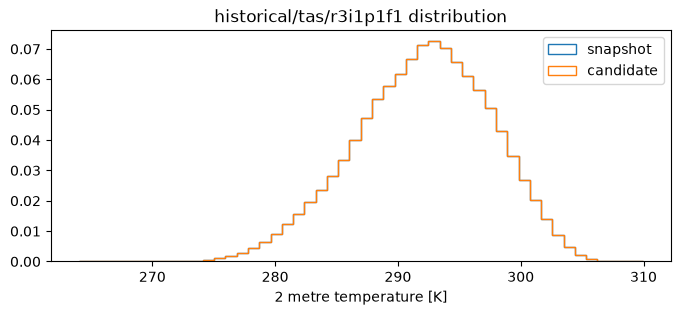

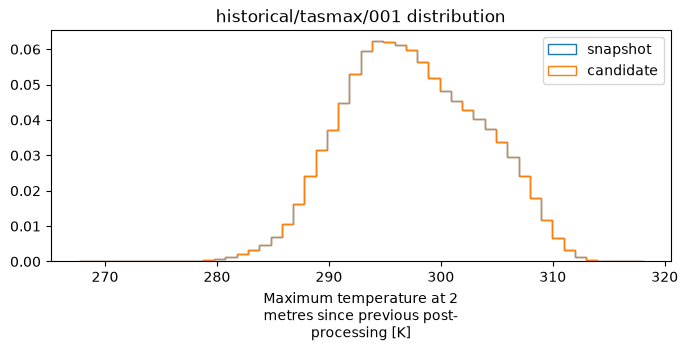

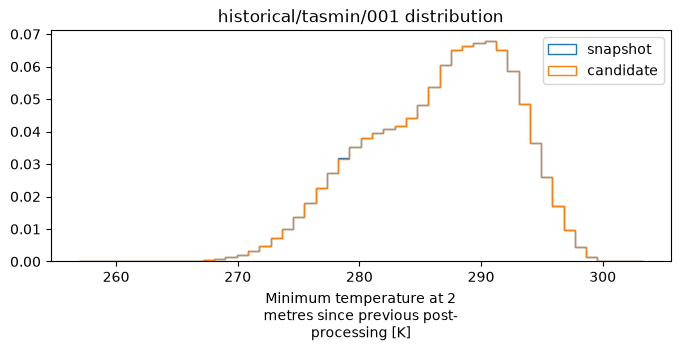

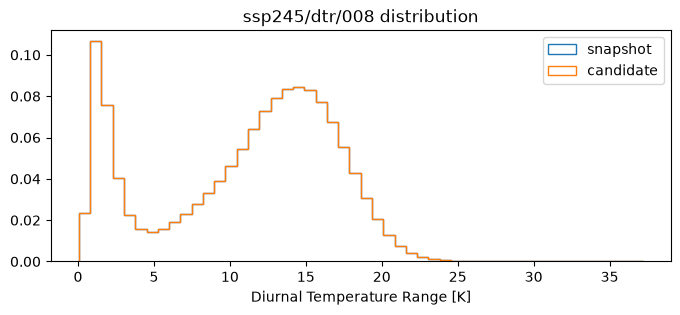

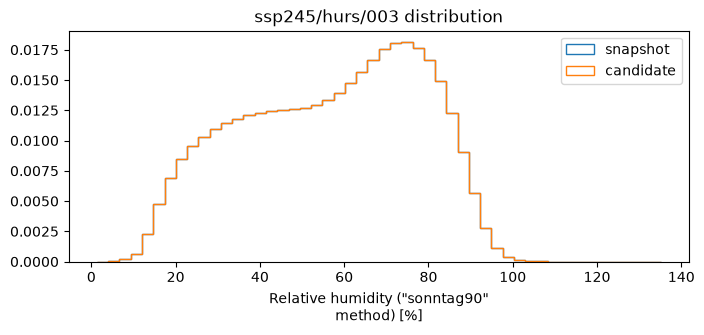

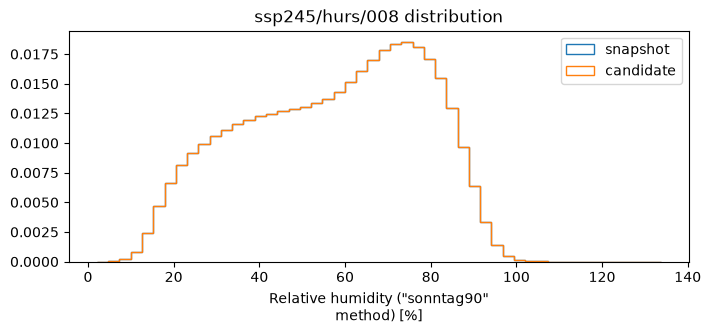

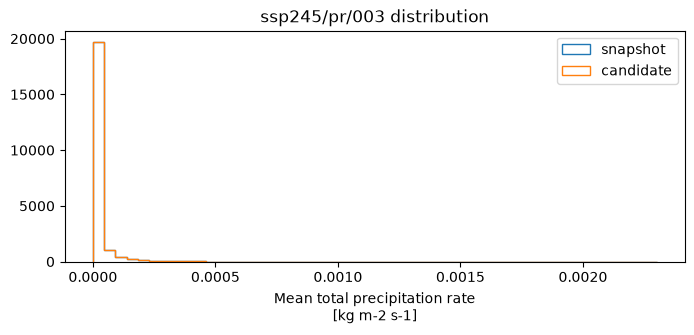

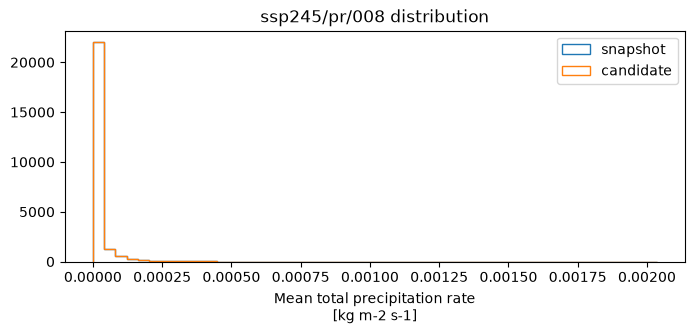

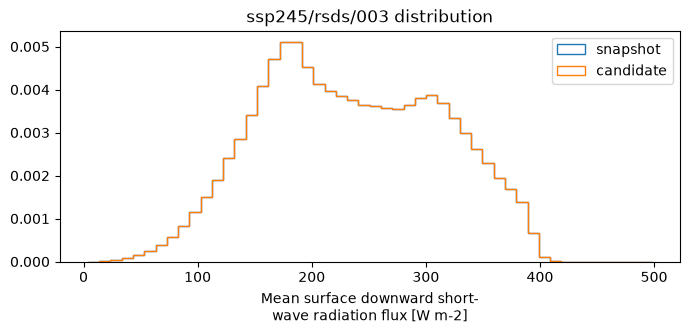

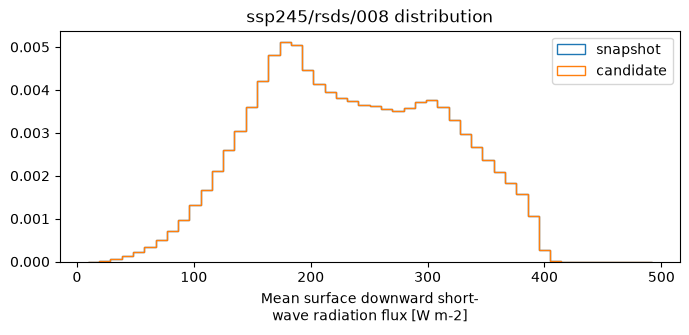

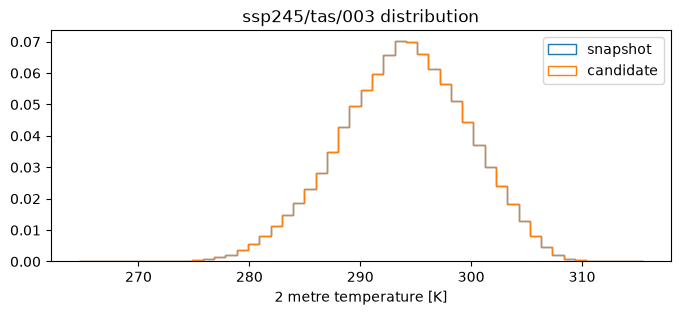

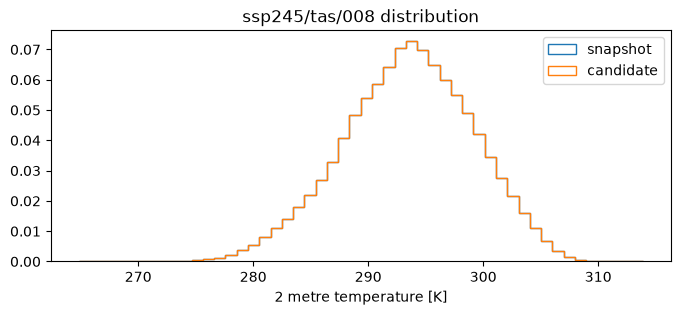

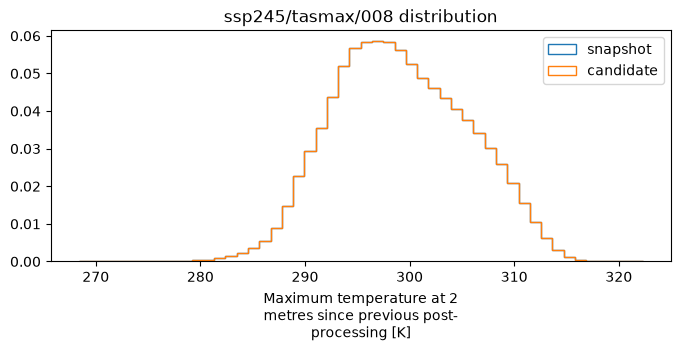

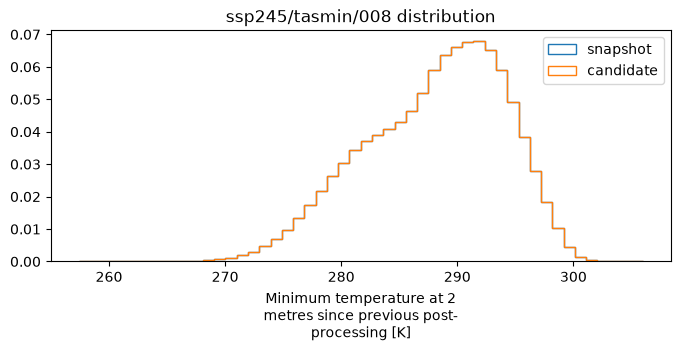

In [9]:
# Value distributions: snapshot vs candidate, per scenario/variable/member.
for scenario in scen_list:
    snap_vars = set(snapshot_tree[scenario].children)
    cand_vars = set(candidate_tree[scenario].children)
    for variable in sorted(snap_vars & cand_vars):
        if variables and variable not in variables:
            continue
        for member in shared_members(scenario, variable):
            s = leaf_da(snapshot_tree, scenario, variable, member)
            c = leaf_da(candidate_tree, scenario, variable, member)
            fig, ax = plt.subplots(figsize=(8, 3))
            s.plot.hist(bins=50, histtype="step", density=True, ax=ax, label="snapshot")
            c.plot.hist(bins=50, histtype="step", density=True, ax=ax, label="candidate")
            ax.set_title(f"{scenario}/{variable}/{member} distribution")
            ax.legend()
            plt.show()

## Verdict

The three passes are reported separately, because they fail for different reasons and call
for different responses. A missing leaf means the run did not finish and must be rerun
before anything else here can be read. A candidate NaN means a gate did not hold. Leaves
out of tolerance are the judgment call described in
`docs/how-to/run-snapshot-tests.md`, and for this branch none are expected: the only behaviour change is scoped to
`G6-1.5K-END`, which has no baseline counterpart to drift against.

In [10]:
print("inventory:      ", "PASS" if inventory_ok else "FAIL")
print("candidate NaN:  ", "PASS" if not candidate_nan_leaves else "FAIL")
print(
    "vs snapshot:    ",
    "PASS (no change beyond tolerance)" if report.passed else "FAIL (changes detected)",
)
for path in never_written:
    print(f"  configured but never written: {path}")
for path in snapshot_only:
    print(f"  snapshot only, not compared: {path}")
for leaf_path, frac, _ in candidate_nan_leaves:
    print(f"  candidate holds NaN inside the ROI: {leaf_path}  frac={frac:.6f}")
for leaf in sorted(report.leaves, key=lambda lf: lf.path):
    if not leaf.within_tol:
        print(
            f"  changed: {leaf.path}  max_abs={leaf.max_abs_diff:.3e}  "
            f"frac>tol={leaf.frac_over_tol:.3e}  nan_mismatch={leaf.nan_mismatch_count}"
        )
for check in sorted(report.invariant_checks, key=lambda c: c.path):
    if not check.holds:
        print(f"  invariant broken: {check.path}  {check.detail}")

inventory:       FAIL
candidate NaN:   PASS
vs snapshot:     FAIL (changes detected)
  changed: debiased_coarse/g6_1p5k/dtr/002/dtr  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/hurs/002/hurs  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/pr/002/pr  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/rsds/002/rsds  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/tas/002/tas  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/tasmax/002/tasmax  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k/tasmin/002/tasmin  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k_end/dtr/002/dtr  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiased_coarse/g6_1p5k_end/hurs/002/hurs  max_abs=nan  frac>tol=1.000e+00  nan_mismatch=-1
  changed: debiase